In [1]:
import os

# # plot params
# plt.style.use('seaborn-whitegrid')
# plt.rc('font', size=11)
# plt.rc('legend', fontsize=11)
# plt.rc('lines', linewidth=2)
# plt.rc('axes', linewidth=2)
# plt.rc('axes', edgecolor='k')
# plt.rc('xtick.major', width=2)
# plt.rc('xtick.major', size=6)
# plt.rc('ytick.major', width=2)
# plt.rc('ytick.major', size=6)
# plt.rc('pdf', fonttype=42)
# plt.rc('ps', fonttype=42)
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from situation_testing.situation_testing import SituationTesting

# -----------------------------
# Publication-quality settings
# -----------------------------

sns.set_theme(style="whitegrid")

mpl.rcParams.update({

    # Font
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # Lines
    "lines.linewidth": 1.5,
    "axes.linewidth": 1.0,

    # Ticks
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4,
    "ytick.major.size": 4,

    # Export settings
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",

    # Figure
    "figure.figsize": (6.5, 4.5),
    "figure.constrained_layout.use": True,
})

# Colorblind-safe palette
palette = {
    "ctr": "#4C72B0",
    "tst-st": "#55A868",
    "tst-cf": "#C44E52",
}

In [2]:
# working directory
wd = os.path.dirname(os.getcwd())
# relevant folders
data_path = os.path.abspath(os.path.join(wd, 'data')) + '\\'
resu_path = os.path.abspath(os.path.join(wd, 'results')) + '\\'
figs_path = os.path.abspath(os.path.join(wd, 'figures')) + '\\'

In [3]:
# our decision maker
b1 = 0.6
b2 = 0.4
min_score = round(b1*3.93 + b2*46.1, 2)  # 20.8
max_score = round(b1*4.00 + b2*48.00)    # 22

In [4]:
# org_df -> df: load and modify factual data accordingly
org_df = pd.read_csv(data_path + 'LawSchool.csv', sep='|').reset_index(drop=True)
df = org_df[['sex', 'race_nonwhite', 'LSAT', 'UGPA']].copy()
df.rename(columns={'sex': 'Gender', 'race_nonwhite': 'Race'}, inplace=True)
# add the decision maker
df['Score'] = b1*df['UGPA'] + b2*df['LSAT']
df['Y'] = np.where(df['Score'] >= min_score, 1, 0)
df.head(5)

,Gender,Race,LSAT,UGPA,Score,Y
0,Female,White,39.0,3.1,17.46,0
1,Female,White,36.0,3.0,16.20,0
2,Male,White,30.0,3.1,13.86,0
3,Male,NonWhite,39.0,2.2,16.92,0
4,Female,White,37.0,3.4,16.84,0


### $|\mathbf{A}=1|$: Gender

In [5]:
do = 'Male'
# org_cf_df -> cf_df
org_cf_df = pd.read_csv(data_path + f'cf_LawSchool_lev3_do{do}.csv', sep='|').reset_index(drop=True)
org_cf_df = org_cf_df.rename(columns={'Sex': 'Gender', 'scf_LSAT': 'LSAT', 'scf_UGPA': 'UGPA'})
cf_df = org_cf_df[['Gender', 'Race', 'LSAT', 'UGPA']].copy()
# add the decision maker
cf_df['Score'] = b1*cf_df['UGPA'] + b2*cf_df['LSAT']
cf_df['Y'] = np.where(cf_df['Score'] >= min_score, 1, 0)
cf_df.head(5)

,Gender,Race,LSAT,UGPA,Score,Y
0,Female,White,39.609,2.975,17.6286,0
1,Female,White,36.609,2.875,16.3686,0
2,Male,White,30.000,3.100,13.8600,0
3,Male,NonWhite,39.000,2.200,16.9200,0
4,Female,White,37.609,3.275,17.0086,0


In [6]:
# store do:=Male results
m_res_df = df[['Gender', 'Race', 'Y']].copy()
m_res_df['cf_Y'] = cf_df[['Y']].copy()
m_res_df.head(5)

,Gender,Race,Y,cf_Y
0,Female,White,0,0
1,Female,White,0,0
2,Male,White,0,0
3,Male,NonWhite,0,0
4,Female,White,0,0


In [7]:
# --- attribute-specific params
feat_trgt = 'Y'
feat_trgt_vals = {'positive': 1, 'negative': 0}
# list of relevant features
feat_rlvt = ['LSAT', 'UGPA']
# protected feature
feat_prot = 'Gender'
# values for the protected feature: use 'non_protected' and 'protected' accordingly
feat_prot_vals = {'non_protected': 'Male', 'protected': 'Female'}

# --- st-specific params
# size of neighborhoods
n = 100
# significance level
alpha = 0.05
# tau diviation
tau = 0.0

#### Standard ST (stST)

In [8]:
test_df = df.copy()

st = SituationTesting()

st.setup_baseline(
    test_df,
    nominal_atts=['Gender'],
    continuous_atts=['LSAT', 'UGPA']
)

m_res_df['stST'] = st.run(
    target_att=feat_trgt,
    target_val=feat_trgt_vals,
    sensitive_att=feat_prot,
    sensitive_val=feat_prot_vals,
    k=n,
    alpha=alpha,
    tau=tau
)

In [9]:
m_res_df[(m_res_df['stST'] > tau)].shape[0]

258

#### Counterfactual Situation Testing (cfST)

In [10]:
test_df    = df.copy()
test_cf_df = cf_df.copy()

cf_st = SituationTesting()

cf_st.setup_baseline(
    test_df, test_cf_df,
    nominal_atts=['Gender'],
    continuous_atts=['LSAT', 'UGPA']
)

m_res_df['cfST'] = cf_st.run(
    target_att=feat_trgt,
    target_val=feat_trgt_vals,
    sensitive_att=feat_prot,
    sensitive_val=feat_prot_vals,
    include_centers=False,
    k=n,
    alpha=alpha,
    tau=tau
)

In [11]:
m_res_df[(m_res_df['cfST'] > tau)].shape[0]

296

In [12]:
# get all neighborhoods for ST
stST_knn = st.res_dict_df_neighbors
# get all neighnorhoods for cfST
cfST_knn = cf_st.res_dict_df_neighbors

In [13]:
# replicate for paper
test_c = [14822, 1349, 20293, 21272, 13031, 16588, 750]

# # complainants in both stST and cfST
# set1 = m_res_df[(m_res_df['stST'] > tau) & (m_res_df['cfST'] > tau)].index.to_list()
# print(len(set1))
# # let's look at those c's that appear both in stST and cfST
# test_n = 7
# test_c = random.sample(set1, test_n)
# # test_c = random.sample(set2, test_n)

In [14]:
print(test_c)

var = ['LSAT', 'UGPA']
temp_df_list = []

for c in test_c:

    temp_ctr = org_df.iloc[stST_knn[c]['ctr_idx'], :][var].copy()
    temp_ctr['ID'] = str(c)
    temp_ctr['Type'] = 'ctr'
    temp_df_list.append(temp_ctr)
    del temp_ctr

    temp_tst_st = org_df.iloc[stST_knn[c]['tst_idx'], :][var].copy()
    temp_tst_st['ID'] = str(c)
    temp_tst_st['Type'] = 'tst-st'
    temp_df_list.append(temp_tst_st)
    del temp_tst_st

    temp_tst_cf = org_cf_df.iloc[cfST_knn[c]['tst_idx'], :][var].copy()
    temp_tst_cf['ID'] = str(c)
    temp_tst_cf['Type'] = 'tst-cf'
    temp_df_list.append(temp_tst_cf)
    del temp_tst_cf

box_plot_data = pd.concat(temp_df_list)
del temp_df_list

[14822, 1349, 20293, 21272, 13031, 16588, 750]


In [15]:
# # box_plot_data
# plt.ylim(42, 49)
# sns.boxplot(x = box_plot_data['ID'],
#             y = box_plot_data['LSAT'],
#             hue = box_plot_data['Type']).set(ylabel = 'LSAT', xlabel = 'Female Complainant ID')

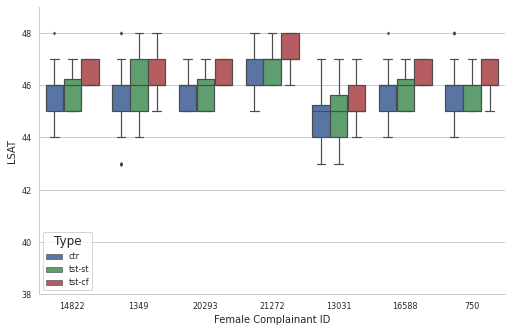

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=box_plot_data,
    x="ID",
    y="LSAT",
    hue="Type",
    palette=palette,
    linewidth=1.2,
    fliersize=2,
    ax=ax,
)

ax.set_xlabel("Female Complainant ID")
ax.set_ylabel("LSAT")
ax.set_ylim(38, 49)

ax.legend(title="Type")

sns.despine()

fig.savefig(figs_path + "boxplot_gender_lsat.pdf")
fig.savefig(figs_path + "boxplot_gender_lsat.png", dpi=600)

In [17]:
# # box_plot_data
# plt.ylim(3.2, 4.2)
# sns.boxplot(x = box_plot_data['ID'],
#             y = box_plot_data['UGPA'],
#             hue = box_plot_data['Type']).set(ylabel = 'UGPA', xlabel = 'Female Complainant ID')

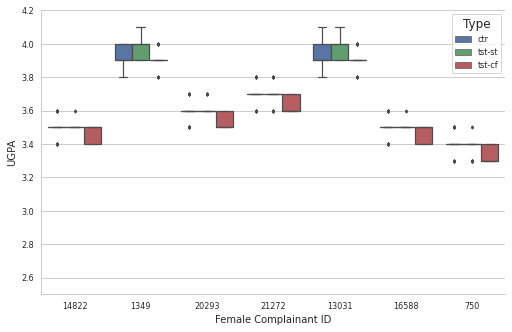

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=box_plot_data,
    x="ID",
    y="UGPA",
    hue="Type",
    palette=palette,
    linewidth=1.2,
    fliersize=2,
    ax=ax,
)

ax.set_xlabel("Female Complainant ID")
ax.set_ylabel("UGPA")
ax.set_ylim(2.5, 4.2)

ax.legend(title="Type")

sns.despine()

fig.savefig(figs_path + "boxplot_gender_ugpa.pdf")
fig.savefig(figs_path + "boxplot_gender_ugpa.png", dpi=600)

### $|\mathbf{A}=1|$: Race

In [19]:
do = 'White'
# org_cf_df -> cf_df
org_cf_df = pd.read_csv(data_path + '\\' + f'cf_LawSchool_lev3_do{do}.csv', sep='|').reset_index(drop=True)
org_cf_df = org_cf_df.rename(columns={'Sex': 'Gender', 'scf_LSAT': 'LSAT', 'scf_UGPA': 'UGPA'})
cf_df = org_cf_df[['Gender', 'Race', 'LSAT', 'UGPA']].copy()
# add the decision maker
cf_df['Score'] = b1*cf_df['UGPA'] + b2*cf_df['LSAT']
cf_df['Y'] = np.where(cf_df['Score'] >= min_score, 1, 0)
cf_df.head(5)

,Gender,Race,LSAT,UGPA,Score,Y
0,Female,White,39.000,3.100,17.460,0
1,Female,White,36.000,3.000,16.200,0
2,Male,White,30.000,3.100,13.860,0
3,Male,NonWhite,43.639,2.419,18.907,0
4,Female,White,37.000,3.400,16.840,0


In [20]:
# store do:=White results
w_res_df = df[['Gender', 'Race', 'Y']].copy()
w_res_df['cf_Y'] = cf_df[['Y']].copy()
w_res_df.head(5)

,Gender,Race,Y,cf_Y
0,Female,White,0,0
1,Female,White,0,0
2,Male,White,0,0
3,Male,NonWhite,0,0
4,Female,White,0,0


In [21]:
# attribute-specific params
feat_trgt = 'Y'
feat_trgt_vals = {'positive': 1, 'negative': 0}
# list of relevant features
feat_rlvt = ['LSAT', 'UGPA']
# protected feature
feat_prot = 'Race'
# values for the protected feature: use 'non_protected' and 'protected' accordingly
feat_prot_vals = {'non_protected': 'White', 'protected': 'NonWhite'}

# st-specific params
# size of neiuborhoods
n = 100
# significance level
alpha = 0.05
# tau diviation
tau = 0.0

#### Standard ST (stST)

In [22]:
test_df = df.copy()

st = SituationTesting()

st.setup_baseline(
    test_df,
    nominal_atts=['Race'],
    continuous_atts=['LSAT', 'UGPA']
)

w_res_df['stST'] = st.run(
    target_att=feat_trgt,
    target_val=feat_trgt_vals,
    sensitive_att=feat_prot,
    sensitive_val=feat_prot_vals,
    k=n,
    alpha=alpha,
    tau=tau
)

In [23]:
w_res_df[(w_res_df['stST'] > tau)].shape[0]

58

#### Counterfactual Situation Testing (cfST)

In [24]:
test_df    = df.copy()
test_cf_df = cf_df.copy()

cf_st = SituationTesting()

cf_st.setup_baseline(
    test_df,
    test_cf_df,
    nominal_atts=['Race'],
    continuous_atts=['LSAT', 'UGPA']
)

w_res_df['cfST'] = cf_st.run(
    target_att=feat_trgt,
    target_val=feat_trgt_vals,
    sensitive_att=feat_prot,
    sensitive_val=feat_prot_vals,
    include_centers=False,
    k=n,
    alpha=alpha,
    tau=tau
)

In [25]:
w_res_df[(w_res_df['cfST'] > tau)].shape[0]

337

In [26]:
# get all neighborhoods for ST
stST_knn = st.res_dict_df_neighbors
# get all neighnorhoods for cfST
cfST_knn = cf_st.res_dict_df_neighbors

In [27]:
# replicate for paper
test_c = [12877, 8072, 4281, 10501, 721, 21558]

# # complainants in both stST and cfST
# set1 = w_res_df[(w_res_df['stST'] > tau) & (w_res_df['cfST'] > tau)].index.to_list()
# print(len(set1))
# # let's look at those c's that appear both in stST and cfST
# test_n = 7
# test_c = random.sample(set1, test_n)
# # test_c = random.sample(set2, test_n)

In [28]:
print(test_c)

var = ['LSAT', 'UGPA']
temp_df_list = []

for c in test_c:

    temp_ctr = org_df.iloc[stST_knn[c]['ctr_idx'], :][var].copy()
    temp_ctr['ID'] = str(c)
    temp_ctr['Type'] = 'ctr'
    temp_df_list.append(temp_ctr)
    del temp_ctr

    temp_tst_st = org_df.iloc[stST_knn[c]['tst_idx'], :][var].copy()
    temp_tst_st['ID'] = str(c)
    temp_tst_st['Type'] = 'tst-st'
    temp_df_list.append(temp_tst_st)
    del temp_tst_st

    temp_tst_cf = org_cf_df.iloc[cfST_knn[c]['tst_idx'], :][var].copy()
    temp_tst_cf['ID'] = str(c)
    temp_tst_cf['Type'] = 'tst-cf'
    temp_df_list.append(temp_tst_cf)
    del temp_tst_cf

box_plot_data = pd.concat(temp_df_list)
del temp_df_list

[12877, 8072, 4281, 10501, 721, 21558]


In [29]:
# # box_plot_data
# plt.ylim(38, 49)
# sns.boxplot(x = box_plot_data['ID'],
#             y = box_plot_data['LSAT'],
#             hue = box_plot_data['Type']).set(ylabel = 'LSAT', xlabel = 'Non-white Complainant ID')

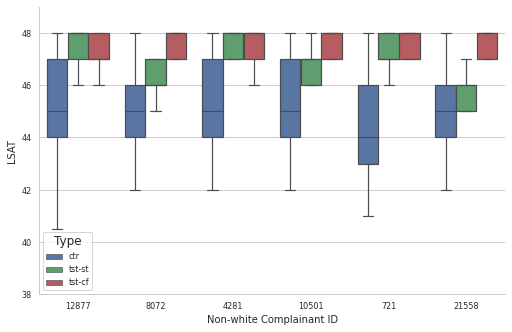

In [30]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=box_plot_data,
    x="ID",
    y="LSAT",
    hue="Type",
    palette=palette,
    linewidth=1.2,
    fliersize=2,
    ax=ax,
)

ax.set_xlabel("Non-white Complainant ID")
ax.set_ylabel("LSAT")
ax.set_ylim(38, 49)

ax.legend(title="Type")

sns.despine()

fig.savefig(figs_path + "boxplot_race_lsat.pdf")
fig.savefig(figs_path + "boxplot_race_lsat.png", dpi=600)

In [31]:
# # box_plot_data
# plt.ylim(2.5, 4.2)
# sns.boxplot(x = box_plot_data['ID'],
#             y = box_plot_data['UGPA'],
#             hue = box_plot_data['Type']).set(ylabel = 'UGPA', xlabel = 'Non-White Complainant ID')

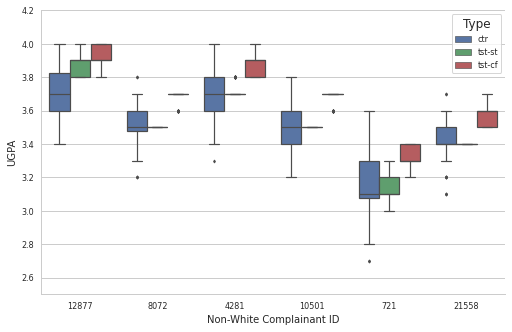

In [32]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=box_plot_data,
    x="ID",
    y="UGPA",
    hue="Type",
    palette=palette,
    linewidth=1.2,
    fliersize=2,
    ax=ax,
)

ax.set_xlabel("Non-White Complainant ID")
ax.set_ylabel("UGPA")
ax.set_ylim(2.5, 4.2)

ax.legend(title="Type")

sns.despine()

fig.savefig(figs_path + "boxplot_race_ugpa.pdf")
fig.savefig(figs_path + "boxplot_race_ugpa.png", dpi=600)